In [1]:
import sys
print(sys.executable)

/usr/local/bin/python3


In [2]:
import os
import certifi

os.environ["SSL_CERT_FILE"] = certifi.where()
os.environ["REQUESTS_CA_BUNDLE"] = certifi.where()
os.environ["TF_USE_LEGACY_KERAS"] = "1"

In [3]:
%pip install "tensorflow>=2.0.0"
%pip install "tensorflow-hub>=0.6.0"
%pip install matplotlib numpy scipy
%pip install tf-keras


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
import matplotlib.pylab as plt
import numpy as np
import tensorflow as tf
import tensorflow_hub as hub
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [5]:
# define the image shape, train_dir, validation_dir, and test_dir
IMAGE_SHAPE = (224,224)
train_dir = '/Users/fefdiniz/Documents/Documentos-MacBookProdeFernanda/UnB/Fastcamp/FastCamp-Dados-Sinteticos/card08/render/train'
validation_dir  = '/Users/fefdiniz/Documents/Documentos-MacBookProdeFernanda/UnB/Fastcamp/FastCamp-Dados-Sinteticos/card08/render/val'
test_dir = '/Users/fefdiniz/Documents/Documentos-MacBookProdeFernanda/UnB/Fastcamp/FastCamp-Dados-Sinteticos/card08/render/test'

In [6]:
# create a training image generator and data generator
train_image_generator = ImageDataGenerator(rescale=1./255)
train_data_gen = train_image_generator.flow_from_directory(directory=train_dir, shuffle=True, target_size=IMAGE_SHAPE)

Found 900 images belonging to 3 classes.


In [7]:
# create a validation image generator and data generator
validation_image_generator = ImageDataGenerator(rescale=1./255)
validation_data_gen = validation_image_generator.flow_from_directory(directory=validation_dir, shuffle=True, target_size=IMAGE_SHAPE)

Found 240 images belonging to 3 classes.


In [8]:
# create a test image generator and data generator
test_image_generator = ImageDataGenerator(rescale=1./255)
test_data_gen = test_image_generator.flow_from_directory(directory=test_dir, shuffle=True, target_size=IMAGE_SHAPE)

Found 30 images belonging to 3 classes.


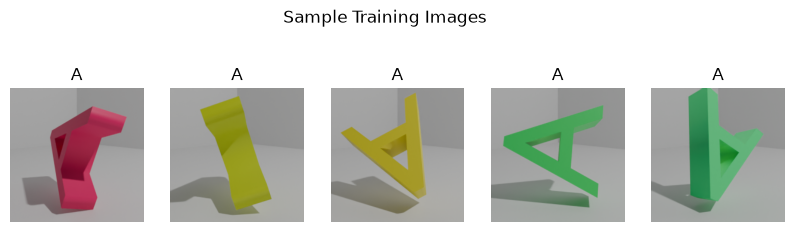

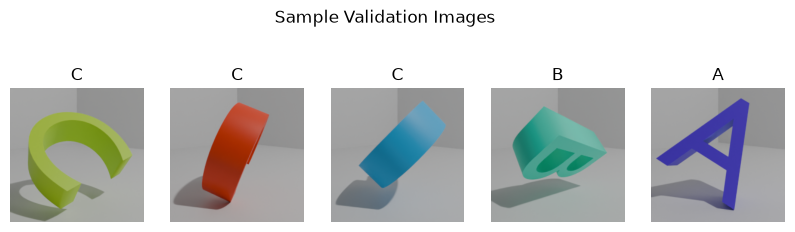

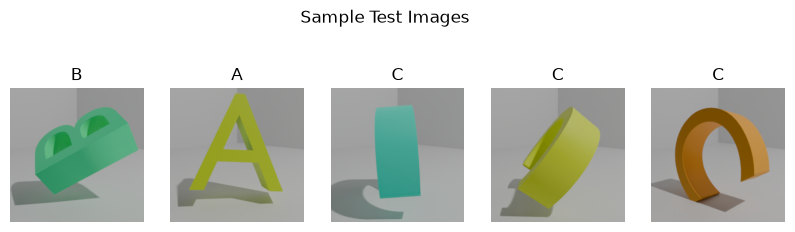

In [9]:
# display sample images from the training, validation, and test datasets
def display_samples(data_gen, title):
    # make a lookup dictionary for class indexes
    classes = dict()

    for key, val in data_gen.class_indices.items():
        classes[val] = key

    # get a sample images and labels
    sample_images, sample_labels = next(data_gen)

    # plot the images and labels
    plt.figure (figsize = (10,3))
    plt.subplots_adjust(hspace=0.5)
    for n in range(5):
        plt.subplot(1,5,n+1)
        plt.imshow(sample_images[n])
        plt.title(classes[np.argmax(sample_labels[n])])
        plt.axis('off')
    _ = plt.suptitle(title)

display_samples(train_data_gen, 'Sample Training Images')
display_samples(validation_data_gen, 'Sample Validation Images')
display_samples(test_data_gen, 'Sample Test Images')

In [10]:
# create a tensorflow model for classifying images
num_classes = len(train_data_gen.class_indices)
model = tf.keras.Sequential([
    hub.KerasLayer("https://tfhub.dev/google/imagenet/mobilenet_v2_100_224/feature_vector/5", 
    trainable=False, input_shape=IMAGE_SHAPE+(3,)), # (224, 224, 3),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

# print out the model summary
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 keras_layer (KerasLayer)    (None, 1280)              2257984   
                                                                 
 dense (Dense)               (None, 3)                 3843      
                                                                 
Total params: 2261827 (8.63 MB)
Trainable params: 3843 (15.01 KB)
Non-trainable params: 2257984 (8.61 MB)
_________________________________________________________________


In [12]:
# compile the model
model.compile(
    optimizer=tf.keras.optimizers.legacy.Adam(), 
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True), 
    metrics=['acc']
)  

In [14]:
# training
# calculate the train & val steps per epoch
train_steps_per_epoch = np.ceil(train_data_gen.samples/train_data_gen.batch_size)
val_steps_per_epoch = np.ceil(validation_data_gen.samples/validation_data_gen.batch_size)

# train the model
epochs = 10
history = model.fit(
    train_data_gen,
    epochs = epochs,
    steps_per_epoch = train_steps_per_epoch,
    validation_data = validation_data_gen,
    validation_steps = val_steps_per_epoch)

Epoch 1/10
29/29 [==============================] - 3s 117ms/step - loss: 0.1594 - acc: 0.9567 - val_loss: 0.2342 - val_acc: 0.9208
Epoch 2/10
29/29 [==============================] - 3s 113ms/step - loss: 0.1421 - acc: 0.9611 - val_loss: 0.2340 - val_acc: 0.9167
Epoch 3/10
29/29 [==============================] - 3s 113ms/step - loss: 0.1260 - acc: 0.9689 - val_loss: 0.2243 - val_acc: 0.9167
Epoch 4/10
29/29 [==============================] - 3s 114ms/step - loss: 0.1139 - acc: 0.9722 - val_loss: 0.2008 - val_acc: 0.9292
Epoch 5/10
29/29 [==============================] - 3s 117ms/step - loss: 0.1073 - acc: 0.9756 - val_loss: 0.1946 - val_acc: 0.9333
Epoch 6/10
29/29 [==============================] - 3s 115ms/step - loss: 0.0950 - acc: 0.9800 - val_loss: 0.1887 - val_acc: 0.9375
Epoch 7/10
29/29 [==============================] - 3s 119ms/step - loss: 0.0884 - acc: 0.9811 - val_loss: 0.1745 - val_acc: 0.9458
Epoch 8/10
29/29 [==============================] - 4s 127ms/step - loss: 0.

In [15]:
# inference
# make a lookup numpy array for class names
class_names = np.empty([len(test_data_gen.class_indices)], dtype = object, order='C')
for key, val in test_data_gen.class_indices.items():
    class_names[val] = key

# get a test batch of images and labels
test_data_gen.reset()
image_batch, label_batch = next (test_data_gen)

# predict the classes of each images using our model
predicted_batch = model.predict(image_batch)
predicted_id = np.argmax(predicted_batch, axis=-1)
predicted_label_batch = class_names[predicted_id]
label_id = np.argmax(label_batch, axis=-1)

1/1 [==============================] - 0s 267ms/step


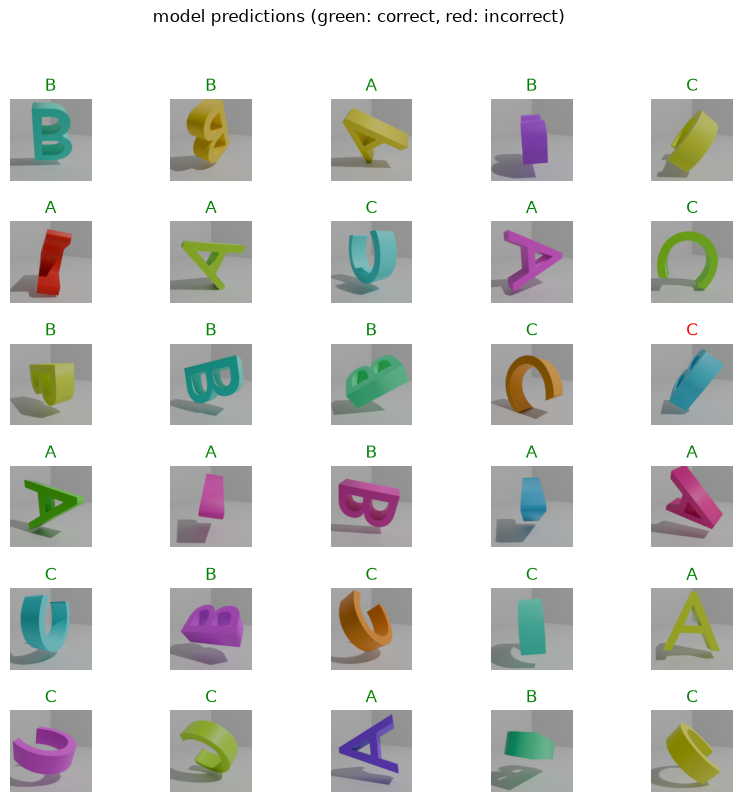

In [16]:
# show predictions
plt.figure(figsize=(10, 9))
plt.subplots_adjust(hspace=0.5)
for n in range(min(30, len(image_batch))):
    plt.subplot(6, 5, n+1)
    plt.imshow(image_batch[n])
    color = "green" if predicted_id[n] == label_id[n] else "red"
    plt.title(predicted_label_batch[n].title(), color=color)
    plt.axis('off')
    _ = plt.suptitle('model predictions (green: correct, red: incorrect)')